# Approach 3: Adaptive Residual U-Net for Diffusion
## Conditional 1D DDPM with Adap-ResBlocks

PhysioNet Computing in Cardiology Challenge 2025.

Based on `chagas_diffusion.ipynb`. Implements Approach 3 from `pinn_plan.md`: the noise U-Net uses Adap-ResBlocks (per-channel learnable gate alpha, initialized so the residual branch is the identity at init) in place of standard ResBlocks. Otherwise the DDPM pipeline for 12-lead ECGs is unchanged. Covers DDPM training and DDIM sampling; for augmentation (5a) and diffusion-based classification (5b), reuse the corresponding sections from `chagas_diffusion.ipynb`.

M3 Mac settings: 32x[1,2] channels, 1 Adap-ResBlock per level, no self-attention, T=500 training steps, DDIM 25-step inference, gradient accumulation for effective batch size 16, ~487K params.

Noise schedule: cosine. Time embedding: sinusoidal + MLP. Class conditioning: AdaGN.

References: Ho et al. 2020 (DDPM); Nichol & Dhariwal 2021 (Improved DDPM); Song et al. 2021 (DDIM); Ho & Salimans 2022 (CFG); Alcaraz et al. 2023 (SSM-conditioned ECG diffusion).

Prerequisite: run `chagas_resnet_classifier.ipynb` first to populate the preprocessing cache.

---
# 1. Environment Setup & Configuration

In [20]:
import os
import math
import time
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("chagas_diffusion")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device}")

PyTorch 2.10.0
Device : mps (Apple Silicon GPU)


In [21]:

CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction":       0.15,
    "test_fraction":      0.15,
    "random_seed":        42,
    "neg_to_pos_ratio":   5,
    "target_fs":          500,
    "target_duration_s":  10,

    "in_channels":       12,
    "model_channels":    32,
    "channel_mult":      [1, 2],
    "num_res_blocks":    1,
    "attention_levels":  [],
    "dropout":           0.1,
    "num_groups":        8,

    "T":                 500,
    "noise_schedule":    "cosine",
    "beta_start":        1e-4,
    "beta_end":          0.02,

    "num_classes":       2,
    "cfg_dropout":       0.15,
    "guidance_scale":    3.0,

    "ddim_steps":        50,
    "ddim_eta":          0.0,

    "epochs":            50,
    "batch_size":        8,
    "grad_accum_steps":  2,
    "lr":                2e-4,
    "warmup_epochs":     3,
    "weight_decay":      1e-6,
    "ema_decay":         0.999,
    "grad_clip":         1.0,
    "num_workers":       0,
    
    "patience":          10,
    "max_time_hours":    5.0,
    "n_synthetic":       500,

    "classify_T_steps":  5,

    "resnet_base_filters":        64,
    "resnet_num_blocks_per_group": 2,
    "resnet_kernel_size":          7,
    "resnet_dropout":              0.3,
    "resnet_epochs":               20,
    "resnet_lr":                   1e-3,
    "resnet_patience":             5,
    "resnet_weight_decay":         1e-4,
    "resnet_channels":             [64, 64, 64, 64],
    "focal_alpha":                 0.25,
    "focal_gamma":                 2.0,
    "label_smoothing":             0.1,

    "checkpoint_dir":    "checkpoints_diffusion",
}

SEQ_LEN = int(CFG["target_fs"] * CFG["target_duration_s"])
print(f"Sequence length: {SEQ_LEN} samples ({CFG['target_duration_s']}s @ {CFG['target_fs']}Hz)")
print(f"U-Net: {CFG['model_channels']} × {CFG['channel_mult']} (M3 Mac optimized)")
print(f"Diffusion steps: T={CFG['T']} (reduced), DDIM={CFG['ddim_steps']}")
print(f"Effective batch size: {CFG['batch_size']} × {CFG['grad_accum_steps']} = {CFG['batch_size'] * CFG['grad_accum_steps']}")
print(f"Early stopping: patience={CFG['patience']}, max_time={CFG['max_time_hours']}h")

Sequence length: 5000 samples (10s @ 500Hz)
U-Net: 32 × [1, 2] (M3 Mac optimized)
Diffusion steps: T=500 (reduced), DDIM=50
Effective batch size: 8 × 2 = 16
Early stopping: patience=10, max_time=5.0h


---
# 2. Load Preprocessed Data (from ResNet notebook)

We reuse the same preprocessing cache and train/val/test split as in `chagas_resnet_classifier.ipynb`.

In [22]:

cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), (
    f"Cache file '{cache_file}' not found. "
    "Run chagas_resnet_classifier.ipynb first to create it."
)

with h5py.File(cache_file, "r") as f:
    total_samples = f["labels"].shape[0]
    all_labels = f["labels"][:]
    print(f"Cache loaded: {total_samples:,} samples")
    print(f"  Chagas+: {all_labels.sum():,.0f} ({100*all_labels.mean():.1f}%)")
    print(f"  Chagas-: {(1-all_labels).sum():,.0f} ({100*(1-all_labels.mean()):.1f}%)")

n_total = total_samples
n_test = int(n_total * CFG["test_fraction"])
n_val = int(n_total * CFG["val_fraction"])
n_train = n_total - n_val - n_test

np.random.seed(CFG["random_seed"])
indices = np.random.permutation(n_total)
train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

print(f"\nSplit: train={len(train_indices):,} / val={len(val_indices):,} / test={len(test_indices):,}")

with h5py.File(cache_file, "r") as f:
    sample_idx = train_indices[:500]
    sample_signals = f["signals"][np.sort(sample_idx)]
print(f"\nSignal amplitude statistics (500-sample subset):")
print(f"  min={sample_signals.min():.4f}  max={sample_signals.max():.4f}")
print(f"  mean={sample_signals.mean():.4f}  std={sample_signals.std():.4f}")
print(f"  99th pct={np.percentile(np.abs(sample_signals), 99):.4f}")
print(f"  → DDIM clamp at ±5 covers "
      f"{100*np.mean(np.abs(sample_signals) < 5):.1f}% of training signal values")
del sample_signals

Cache loaded: 49,152 samples
  Chagas+: 8,192 (16.7%)
  Chagas-: 40,960 (83.3%)

Split: train=34,408 / val=7,372 / test=7,372

Signal amplitude statistics (500-sample subset):
  min=-20.0060  max=17.1086
  mean=0.0000  std=0.9990
  99th pct=4.5818
  → DDIM clamp at ±5 covers 99.3% of training signal values


In [23]:

class CachedChagasDataset(Dataset):
    """Load preprocessed ECGs from HDF5 cache."""

    def __init__(self, cache_path, indices, transform=None):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self.transform = transform
        self._file = None

        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _get_file(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __del__(self):
        if self._file is not None:
            try:
                self._file.close()
            except Exception:
                pass

    def __getitem__(self, idx):
        f = self._get_file()
        real_idx = self.indices[idx]
        signal = torch.from_numpy(f["signals"][real_idx]).float()
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            signal = self.transform(signal)
        return signal, label

train_ds = CachedChagasDataset(cache_file, train_indices)
val_ds = CachedChagasDataset(cache_file, val_indices)
test_ds = CachedChagasDataset(cache_file, test_indices)

use_pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)

train_labels = train_ds.labels
class_counts = np.bincount(train_labels.astype(int), minlength=2)
print(f"Train: {len(train_ds):,} samples ({len(train_loader):,} batches)")
print(f"Val  : {len(val_ds):,} samples")
print(f"Test : {len(test_ds):,} samples")
print(f"Class balance: {class_counts[0]:,} neg / {class_counts[1]:,} pos")

Train: 34,408 samples (4,301 batches)
Val  : 7,372 samples
Test : 7,372 samples
Class balance: 28,602 neg / 5,806 pos


---
# 3. Evaluation Utilities (reused)

Same metrics as in the ResNet notebook for direct comparison.

In [24]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sensitivity: float
    specificity: float
    threshold: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"),
                          0.0, 0.0, 0.0, threshold)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    challenge_score = calculate_tpr_at_capacity(y_true, y_prob, 0.05)

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0.0)

    return EvalResult(auroc, auprc, challenge_score, f1, sens, spec, threshold)

def find_optimal_threshold(y_true, y_prob, metric="f1", n_thresholds=200):
    best_val, best_thr = -1.0, 0.5
    for thr in np.linspace(0.01, 0.99, n_thresholds):
        result = compute_metrics(y_true, y_prob, threshold=thr)
        val = getattr(result, metric, result.f1)
        if val > best_val:
            best_val, best_thr = val, thr
    return float(best_thr)

def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob > bin_edges[i]) & (y_prob <= bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        ece += mask.sum() / len(y_true) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)

print("\u2713 Evaluation utilities ready.")

✓ Evaluation utilities ready.


---
# 4. Diffusion Process

## 4.1 Noise Schedule

Cosine noise schedule (Nichol & Dhariwal 2021).

In [25]:
def cosine_beta_schedule(T, s=0.008):
    """Cosine noise schedule (Nichol & Dhariwal, 2021)."""
    steps = torch.arange(T + 1, dtype=torch.float64)
    f_t = torch.cos(((steps / T) + s) / (1 + s) * (math.pi / 2)) ** 2
    alphas_cumprod = f_t / f_t[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.999).float()

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Linear noise schedule (Ho et al., 2020)."""
    return torch.linspace(beta_start, beta_end, T)

class DiffusionSchedule:
    """Precomputes all diffusion constants for efficient training/sampling."""

    def __init__(self, T=1000, schedule="cosine", beta_start=1e-4, beta_end=0.02):
        self.T = T

        if schedule == "cosine":
            betas = cosine_beta_schedule(T)
        else:
            betas = linear_beta_schedule(T, beta_start, beta_end)

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

        self.posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )

    def to(self, device):
        for attr in ['betas', 'alphas', 'alphas_cumprod', 'alphas_cumprod_prev',
                      'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod',
                      'sqrt_recip_alphas', 'posterior_variance']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def q_sample(self, x_0, t, noise=None):
        """Forward process: add noise to x_0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None, None]
        return sqrt_alpha * x_0 + sqrt_one_minus * noise

schedule = DiffusionSchedule(
    T=CFG["T"],
    schedule=CFG["noise_schedule"],
    beta_start=CFG["beta_start"],
    beta_end=CFG["beta_end"],
).to(device)

print(f"Diffusion schedule: {CFG['noise_schedule']}, T={CFG['T']}")
print(f"  beta range: [{schedule.betas[0]:.6f}, {schedule.betas[-1]:.6f}]")
print(f"  alpha_bar range: [{schedule.alphas_cumprod[-1]:.6f}, {schedule.alphas_cumprod[0]:.6f}]")

Diffusion schedule: cosine, T=500
  beta range: [0.000100, 0.999000]
  alpha_bar range: [0.000000, 0.999900]


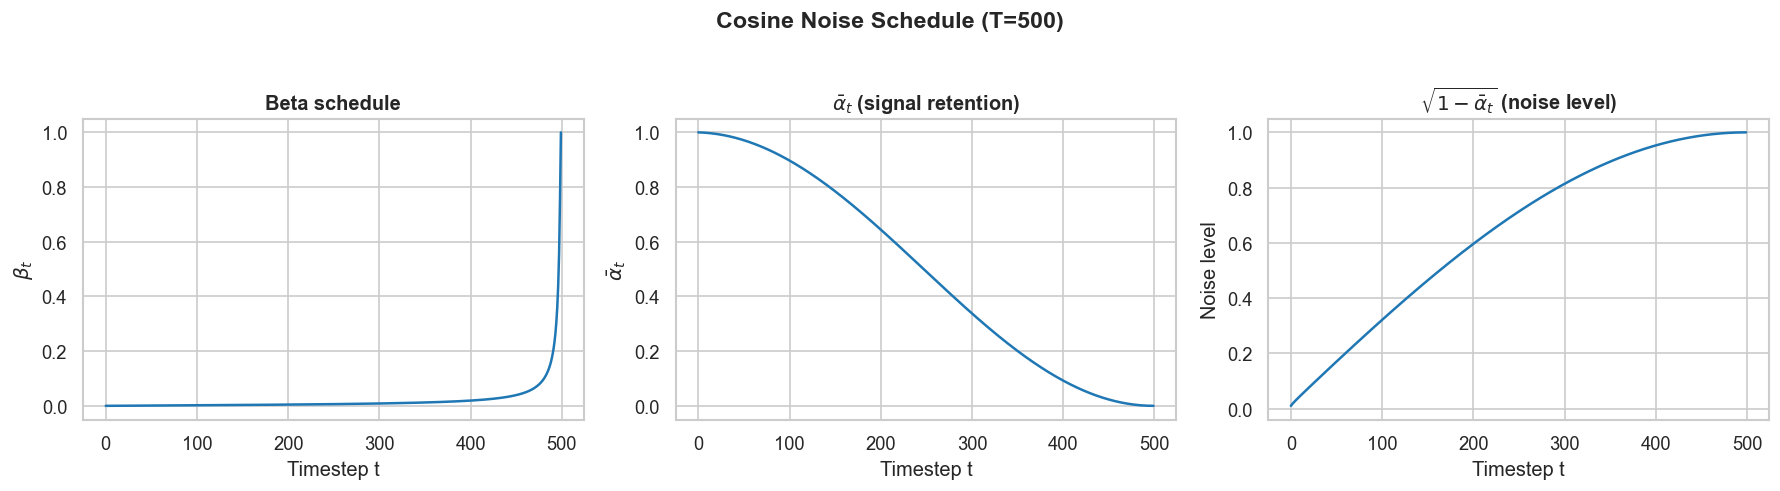

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t_vals = np.arange(CFG["T"])
axes[0].plot(t_vals, schedule.betas.cpu().numpy())
axes[0].set_title("Beta schedule", fontweight="bold")
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel(r"$\beta_t$")

axes[1].plot(t_vals, schedule.alphas_cumprod.cpu().numpy())
axes[1].set_title(r"$\bar{\alpha}_t$ (signal retention)", fontweight="bold")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel(r"$\bar{\alpha}_t$")

axes[2].plot(t_vals, schedule.sqrt_one_minus_alphas_cumprod.cpu().numpy())
axes[2].set_title(r"$\sqrt{1 - \bar{\alpha}_t}$ (noise level)", fontweight="bold")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("Noise level")

plt.suptitle(f"{CFG['noise_schedule'].title()} Noise Schedule (T={CFG['T']})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 5. Model Architecture: Conditional 1D U-Net

Noise network $\epsilon_\theta(x_t, t, y)$ is a 1D U-Net. Timestep enters via sinusoidal embedding + MLP; class label enters via AdaGN. For classifier-free guidance the label is replaced with a null token with probability `cfg_dropout` during training.

Adap-ResBlock: `y = skip(x) + alpha * F(x)`, with `alpha` of shape `(1, C_out, 1)` initialized to zero so each block starts as the identity skip and learns its own per-channel gain on the conv branch.

In [27]:

class SinusoidalPositionEmbedding(nn.Module):
    """Sinusoidal timestep embedding (Vaswani et al., 2017)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class AdaGN(nn.Module):
    """Adaptive Group Normalization — injects time+class conditioning.

    Given features x and conditioning embedding h:
        AdaGN(x, h) = h_s * GroupNorm(x) + h_b
    where h_s, h_b are scale/bias predicted from h.
    """
    def __init__(self, num_channels, cond_dim, num_groups=8):
        super().__init__()
        self.gn = nn.GroupNorm(num_groups, num_channels)
        self.proj = nn.Linear(cond_dim, num_channels * 2)

    def forward(self, x, cond):
        h = self.proj(cond)[:, :, None]
        scale, bias = h.chunk(2, dim=1)
        return (1 + scale) * self.gn(x) + bias

class AdapResBlock1D(nn.Module):
    """Adaptive residual block for 1D U-Net (Adap-ResBlock).

    y = skip(x) + α ⊙ F(x), with F the SiLU–AdaGN–Conv stack and skip the 1×1 projection.

    α is per-channel (shape 1×C_out×1), initialized to zero so at t=0 the nonlinear branch
    is off and y = skip(x) (identity mapping on the residual contribution; stable deep init).
    """
    def __init__(self, in_ch, out_ch, cond_dim, num_groups=8, dropout=0.1):
        super().__init__()
        self.norm1 = AdaGN(in_ch, cond_dim, num_groups)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.norm2 = AdaGN(out_ch, cond_dim, num_groups)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.alpha = nn.Parameter(torch.zeros(1, out_ch, 1))

    def forward(self, x, cond):
        h = F.silu(self.norm1(x, cond))
        h = self.conv1(h)
        h = F.silu(self.norm2(h, cond))
        h = self.dropout(h)
        h = self.conv2(h)
        return self.skip(x) + self.alpha * h

class SelfAttention1D(nn.Module):
    """Multi-head self-attention for 1D sequences."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        b, c, l = x.shape
        h = self.norm(x).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1)

print("\u2713 Building blocks defined (AdapResBlock1D).")

✓ Building blocks defined (AdapResBlock1D).


In [28]:

class ConditionalUNet1D(nn.Module):
    """1D U-Net for noise prediction, conditioned on timestep and class label.

    Uses AdapResBlock1D (gated residuals) instead of plain ResBlocks.
    Supports classifier-free guidance via a learnable null class embedding.
    """
    def __init__(self, in_channels=12, model_channels=64, channel_mult=(1, 2, 4),
                 num_res_blocks=2, attention_levels=(2,), dropout=0.1,
                 num_classes=2, num_groups=8):
        super().__init__()

        self.num_res_blocks = num_res_blocks
        self.num_levels = len(channel_mult)
        cond_dim = model_channels * 4
        self.cond_dim = cond_dim

        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(model_channels),
            nn.Linear(model_channels, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.class_embed = nn.Embedding(num_classes + 1, cond_dim)
        self.null_class_id = num_classes

        self.input_proj = nn.Conv1d(in_channels, model_channels, 3, padding=1)

        self.encoder_blocks = nn.ModuleList()
        self.downsamplers = nn.ModuleList()
        ch = model_channels
        encoder_channels = [ch]

        for level, mult in enumerate(channel_mult):
            out_ch = model_channels * mult
            for _ in range(num_res_blocks):
                layers = [AdapResBlock1D(ch, out_ch, cond_dim, num_groups, dropout)]
                if level in attention_levels:
                    layers.append(SelfAttention1D(out_ch))
                self.encoder_blocks.append(nn.ModuleList(layers))
                ch = out_ch
                encoder_channels.append(ch)

            if level < len(channel_mult) - 1:
                self.downsamplers.append(
                    nn.Conv1d(ch, ch, 4, stride=2, padding=1)
                )
                encoder_channels.append(ch)

        bottleneck_layers = [
            AdapResBlock1D(ch, ch, cond_dim, num_groups, dropout),
        ]
        if len(attention_levels) > 0:
            bottleneck_layers.append(SelfAttention1D(ch))
        bottleneck_layers.append(
            AdapResBlock1D(ch, ch, cond_dim, num_groups, dropout),
        )
        self.bottleneck = nn.ModuleList(bottleneck_layers)

        self.decoder_blocks = nn.ModuleList()
        self.upsamplers = nn.ModuleList()

        for level, mult in reversed(list(enumerate(channel_mult))):
            out_ch = model_channels * mult
            for i in range(num_res_blocks + 1):
                skip_ch = encoder_channels.pop()
                layers = [AdapResBlock1D(ch + skip_ch, out_ch, cond_dim, num_groups, dropout)]
                if level in attention_levels:
                    layers.append(SelfAttention1D(out_ch))
                self.decoder_blocks.append(nn.ModuleList(layers))
                ch = out_ch

            if level > 0:
                self.upsamplers.append(
                    nn.ConvTranspose1d(ch, ch, 4, stride=2, padding=1)
                )

        self.output_norm = nn.GroupNorm(num_groups, ch)
        self.output_proj = nn.Conv1d(ch, in_channels, 3, padding=1)
        nn.init.zeros_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x, t, y=None, cfg_dropout=0.0):
        """
        Args:
            x: (B, C, L) noisy signal
            t: (B,) timestep indices
            y: (B,) class labels (0=neg, 1=pos). None → unconditional.
            cfg_dropout: probability of replacing y with null token (training only)
        Returns:
            predicted noise (B, C, L)
        """
        cond = self.time_embed(t)

        if y is not None:
            if cfg_dropout > 0 and self.training:
                mask = torch.rand(y.shape[0], device=y.device) < cfg_dropout
                y = y.clone()
                y[mask] = self.null_class_id
            cond = cond + self.class_embed(y)
        else:
            null_y = torch.full((x.shape[0],), self.null_class_id,
                               device=x.device, dtype=torch.long)
            cond = cond + self.class_embed(null_y)

        h = self.input_proj(x)
        skips = [h]
        block_idx = 0
        ds_idx = 0

        for level in range(self.num_levels):
            for _ in range(self.num_res_blocks):
                for layer in self.encoder_blocks[block_idx]:
                    h = layer(h, cond) if isinstance(layer, AdapResBlock1D) else layer(h)
                skips.append(h)
                block_idx += 1

            if level < self.num_levels - 1:
                h = self.downsamplers[ds_idx](h)
                skips.append(h)
                ds_idx += 1

        for layer in self.bottleneck:
            h = layer(h, cond) if isinstance(layer, AdapResBlock1D) else layer(h)

        block_idx = 0
        us_idx = 0

        for level in reversed(range(self.num_levels)):
            for _ in range(self.num_res_blocks + 1):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                for layer in self.decoder_blocks[block_idx]:
                    h = layer(h, cond) if isinstance(layer, AdapResBlock1D) else layer(h)
                block_idx += 1

            if level > 0:
                h = self.upsamplers[us_idx](h)
                us_idx += 1

        h = F.silu(self.output_norm(h))
        return self.output_proj(h)

unet = ConditionalUNet1D(
    in_channels=CFG["in_channels"],
    model_channels=CFG["model_channels"],
    channel_mult=CFG["channel_mult"],
    num_res_blocks=CFG["num_res_blocks"],
    attention_levels=CFG["attention_levels"],
    dropout=CFG["dropout"],
    num_classes=CFG["num_classes"],
    num_groups=CFG["num_groups"],
).to(device)

n_params = sum(p.numel() for p in unet.parameters())
print(f"ConditionalUNet1D parameters: {n_params:,}")
print(unet)

ConditionalUNet1D parameters: 487,852
ConditionalUNet1D(
  (time_embed): Sequential(
    (0): SinusoidalPositionEmbedding()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (class_embed): Embedding(3, 128)
  (input_proj): Conv1d(12, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (encoder_blocks): ModuleList(
    (0): ModuleList(
      (0): AdapResBlock1D(
        (norm1): AdaGN(
          (gn): GroupNorm(8, 32, eps=1e-05, affine=True)
          (proj): Linear(in_features=128, out_features=64, bias=True)
        )
        (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (norm2): AdaGN(
          (gn): GroupNorm(8, 32, eps=1e-05, affine=True)
          (proj): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (skip): I

In [29]:

with torch.no_grad():
    dummy_x = torch.randn(2, 12, SEQ_LEN, device=device)
    dummy_t = torch.randint(0, CFG["T"], (2,), device=device)
    dummy_y = torch.tensor([0, 1], device=device)
    out = unet(dummy_x, dummy_t, dummy_y, cfg_dropout=0.1)
    print(f"Input:  {dummy_x.shape}")
    print(f"Output: {out.shape}")
    assert out.shape == dummy_x.shape, "Shape mismatch!"
    print("\u2713 Forward pass OK")

Input:  torch.Size([2, 12, 5000])
Output: torch.Size([2, 12, 5000])
✓ Forward pass OK


---
# 6. EMA (Exponential Moving Average)

Maintain a shadow copy of model weights for stable generation at inference time.

In [30]:
class EMA:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(
                    param.data, alpha=1 - self.decay
                )

    def apply_shadow(self, model):
        """Replace model params with EMA params."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        """Restore original model params."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

ema = EMA(unet, decay=CFG["ema_decay"])
print(f"\u2713 EMA initialized (decay={CFG['ema_decay']})")

✓ EMA initialized (decay=0.999)


---
# 7. DDPM Training

In [31]:

optimizer = AdamW(unet.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

warmup_epochs = CFG.get("warmup_epochs", 0)
main_scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"] - warmup_epochs)
if warmup_epochs > 0:
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[warmup_epochs]
    )
else:
    scheduler = main_scheduler

checkpoint_dir = Path(CFG["checkpoint_dir"])
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"Optimizer: AdamW (lr={CFG['lr']}, wd={CFG['weight_decay']})")
print(f"Scheduler: Warmup({warmup_epochs}ep) + CosineAnnealing({CFG['epochs'] - warmup_epochs}ep)")
print(f"CFG dropout: {CFG['cfg_dropout']}")
print(f"Gradient accumulation: {CFG.get('grad_accum_steps', 1)} steps")

Optimizer: AdamW (lr=0.0002, wd=1e-06)
Scheduler: Warmup(3ep) + CosineAnnealing(47ep)
CFG dropout: 0.15
Gradient accumulation: 2 steps


In [32]:
def train_diffusion_epoch(model, ema, loader, optimizer, schedule, device, cfg,
                          epoch=None, total_epochs=None):
    """Train one epoch of DDPM with gradient accumulation."""
    model.train()
    running_loss, n = 0.0, 0
    accum = cfg.get("grad_accum_steps", 1)

    desc = f"Epoch {epoch}/{total_epochs}" if epoch else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)

    optimizer.zero_grad()

    for step, (x_0, y) in enumerate(pbar):
        x_0, y = x_0.to(device), y.to(device)
        B = x_0.shape[0]

        t = torch.randint(0, cfg["T"], (B,), device=device)
        noise = torch.randn_like(x_0)
        x_t = schedule.q_sample(x_0, t, noise)

        predicted_noise = model(x_t, t, y, cfg_dropout=cfg["cfg_dropout"])
        loss = F.mse_loss(predicted_noise, noise) / accum
        loss.backward()

        running_loss += loss.item() * accum
        n += 1

        if (step + 1) % accum == 0:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip"])
            optimizer.step()
            ema.update(model)
            optimizer.zero_grad()

        pbar.set_postfix({"loss": f"{running_loss/n:.6f}"})
        del x_0, y, x_t, noise, predicted_noise, loss

    if (step + 1) % accum != 0:
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip"])
        optimizer.step()
        ema.update(model)
        optimizer.zero_grad()

    return running_loss / max(n, 1)

@torch.no_grad()
def validate_diffusion(model, loader, schedule, device, cfg):
    """Compute validation loss for DDPM."""
    model.eval()
    running_loss, n = 0.0, 0

    for x_0, y in tqdm(loader, desc="Validating", leave=False):
        x_0, y = x_0.to(device), y.to(device)
        B = x_0.shape[0]
        t = torch.randint(0, cfg["T"], (B,), device=device)
        noise = torch.randn_like(x_0)
        x_t = schedule.q_sample(x_0, t, noise)
        predicted_noise = model(x_t, t, y, cfg_dropout=0.0)
        loss = F.mse_loss(predicted_noise, noise)
        running_loss += loss.item()
        n += 1
        del x_0, y, x_t, noise, predicted_noise, loss

    return running_loss / max(n, 1)

print("\u2713 Training functions defined.")

✓ Training functions defined.


In [ ]:

history = []
best_val_loss = float("inf")
patience = CFG["patience"]
patience_counter = 0
start_epoch = 1

epoch_times = []
training_start_time = time.time()

ckpt_path = checkpoint_dir / "best_ddpm_adapres.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    ckpt_cfg_dropout = ckpt.get("cfg_dropout", None)
    if ckpt_cfg_dropout is not None and ckpt_cfg_dropout != CFG["cfg_dropout"]:
        print(f"⚠ Checkpoint cfg_dropout={ckpt_cfg_dropout} differs from current "
              f"CFG['cfg_dropout']={CFG['cfg_dropout']}. "
              f"Delete the checkpoint and retrain from scratch to avoid mixed configs.")
    else:
        try:
            unet.load_state_dict(ckpt["model_state_dict"])
            best_val_loss = ckpt["val_loss"]
            start_epoch = ckpt["epoch"] + 1
            if "ema_shadow" in ckpt:
                ema.shadow = ckpt["ema_shadow"]
            if "optimizer_state_dict" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            if "scheduler_state_dict" in ckpt:
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
            print(f"Resumed from epoch {ckpt['epoch']} (val_loss={best_val_loss:.6f})")
        except RuntimeError as e:
            print(f"⚠ Checkpoint incompatible with current model — training from scratch.")
            print(f"  (Error: {e})")

print(f"\n🚀 Starting M3 Mac optimized training:")
print(f"   Model: {CFG['model_channels']}×{CFG['channel_mult']}, T={CFG['T']}, {sum(p.numel() for p in unet.parameters()):,} params")
print(f"   Training: {CFG['epochs']} epochs, patience={CFG['patience']}, max_time={CFG['max_time_hours']}h")
print(f"\n{'Epoch':>5} | {'TrainLoss':>10} | {'ValLoss':>10} | {'LR':>9} | {'Time':>6}")
print("-" * 55)

for epoch in range(start_epoch, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss = train_diffusion_epoch(
        unet, ema, train_loader, optimizer, schedule, device, CFG,
        epoch=epoch, total_epochs=CFG["epochs"],
    )

    ema.apply_shadow(unet)
    val_loss = validate_diffusion(unet, val_loader, schedule, device, CFG)
    ema.restore(unet)
    if device.type == "mps":
        torch.mps.empty_cache()

    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_loss, "lr": lr, "time_s": elapsed,
    })

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": unet.state_dict(),
            "ema_shadow": ema.shadow,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "cfg_dropout": CFG["cfg_dropout"],
            "val_loss": val_loss,
        }, checkpoint_dir / "best_ddpm_adapres.pt")
        marker = " ★"
    else:
        patience_counter += 1

    print(f"{epoch:5d} | {train_loss:10.6f} | {val_loss:10.6f} | "
          f"{lr:9.2e} | {elapsed:5.1f}s{marker}")

    scheduler.step()
    
    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()
    
    epoch_times.append(elapsed)
    
    if len(epoch_times) >= 3:
        avg_epoch_time = sum(epoch_times[-3:]) / 3
        remaining_epochs = CFG["epochs"] - epoch
        estimated_remaining_hours = (remaining_epochs * avg_epoch_time) / 3600
        
        if estimated_remaining_hours > CFG["max_time_hours"]:
            print(f"\n⏰ Stopping: estimated remaining time {estimated_remaining_hours:.1f}h > {CFG['max_time_hours']}h")
            break
            
        if epoch % 5 == 0:
            total_elapsed_hours = (time.time() - training_start_time) / 3600
            estimated_total_hours = total_elapsed_hours + estimated_remaining_hours
            print(f"   ETA: {estimated_remaining_hours:.1f}h remaining (~{estimated_total_hours:.1f}h total)")

    if patience_counter >= patience:
        print(f"\n⏹ Early stopping: no improvement for {patience} epochs")
        break

total_training_time = (time.time() - training_start_time) / 3600
print(f"\n✅ Training completed in {total_training_time:.1f}h")
print(f"Best validation loss: {best_val_loss:.6f}")

Resumed from epoch 50 (val_loss=0.962540)

🚀 Starting M3 Mac optimized training:
   Model: 32×[1, 2], T=500, 487,852 params
   Training: 50 epochs, patience=10, max_time=5.0h

Epoch |  TrainLoss |    ValLoss |        LR |   Time
-------------------------------------------------------

✅ Training completed in 0.0h
Best validation loss: 0.962540


---
# 8. Training Curves

In [34]:
if not history:
    print("No new training epochs recorded (resumed from completed checkpoint).")
    print(f"Best validation loss from checkpoint: {best_val_loss:.6f}")
else:
    hist_df = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val")
    axes[0].set_title("MSE Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["lr"])
    axes[1].set_title("Learning Rate", fontweight="bold")
    axes[1].set_xlabel("Epoch")

    axes[2].plot(hist_df["epoch"], hist_df["time_s"])
    axes[2].set_title("Time per Epoch (s)", fontweight="bold")
    axes[2].set_xlabel("Epoch")

    plt.suptitle("DDPM Training History", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

No new training epochs recorded (resumed from completed checkpoint).
Best validation loss from checkpoint: 0.962540


# 9. DDIM Sampling

Deterministic DDIM sampling; ~50 steps instead of 1000.

In [35]:

ckpt_path = checkpoint_dir / "best_ddpm_adapres.pt"
assert ckpt_path.exists(), f"No checkpoint found at {ckpt_path}. Train the model first."

ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
unet.load_state_dict(ckpt["model_state_dict"])

ema_gen = EMA(unet, decay=CFG["ema_decay"])
ema_gen.shadow = ckpt["ema_shadow"]
ema_gen.apply_shadow(unet)

print(f"Loaded best DDPM from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.6f})")
print("EMA weights applied for generation.")

Loaded best DDPM from epoch 50 (val_loss=0.962540)
EMA weights applied for generation.


In [36]:
@torch.no_grad()
def ddim_sample(model, schedule, shape, y, cfg, device,
                steps=50, eta=0.0, guidance_scale=2.0):
    """DDIM sampling with classifier-free guidance.
    
    Args:
        model: noise prediction U-Net
        schedule: DiffusionSchedule
        shape: (B, C, L) output shape
        y: (B,) class labels for conditional generation
        cfg: config dict
        device: torch device
        steps: number of DDIM steps
        eta: DDIM stochasticity (0=deterministic)
        guidance_scale: classifier-free guidance scale (w)
    """
    model.eval()
    B = shape[0]

    step_indices = torch.from_numpy(
        np.round(np.linspace(0, schedule.T - 1, steps + 1)).astype(int)
    )
    timesteps = step_indices.flip(0)

    x = torch.randn(shape, device=device)

    for i in tqdm(range(len(timesteps) - 1), desc="DDIM Sampling", leave=False):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1]

        t_batch = torch.full((B,), t_cur, device=device, dtype=torch.long)

        eps_cond = model(x, t_batch, y, cfg_dropout=0.0)
        eps_uncond = model(x, t_batch, y=None, cfg_dropout=0.0)
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        alpha_bar_t = schedule.alphas_cumprod[t_cur]
        alpha_bar_prev = schedule.alphas_cumprod[t_prev] if t_prev.item() > 0 else torch.tensor(1.0, device=device)

        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-5, 5)

        sigma = eta * torch.sqrt(
            (1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev)
        )
        direction = torch.sqrt(1 - alpha_bar_prev - sigma**2) * eps
        x = torch.sqrt(alpha_bar_prev) * x0_pred + direction

        if sigma > 0:
            x = x + sigma * torch.randn_like(x)

    return x

print("\u2713 DDIM sampling function defined.")

✓ DDIM sampling function defined.


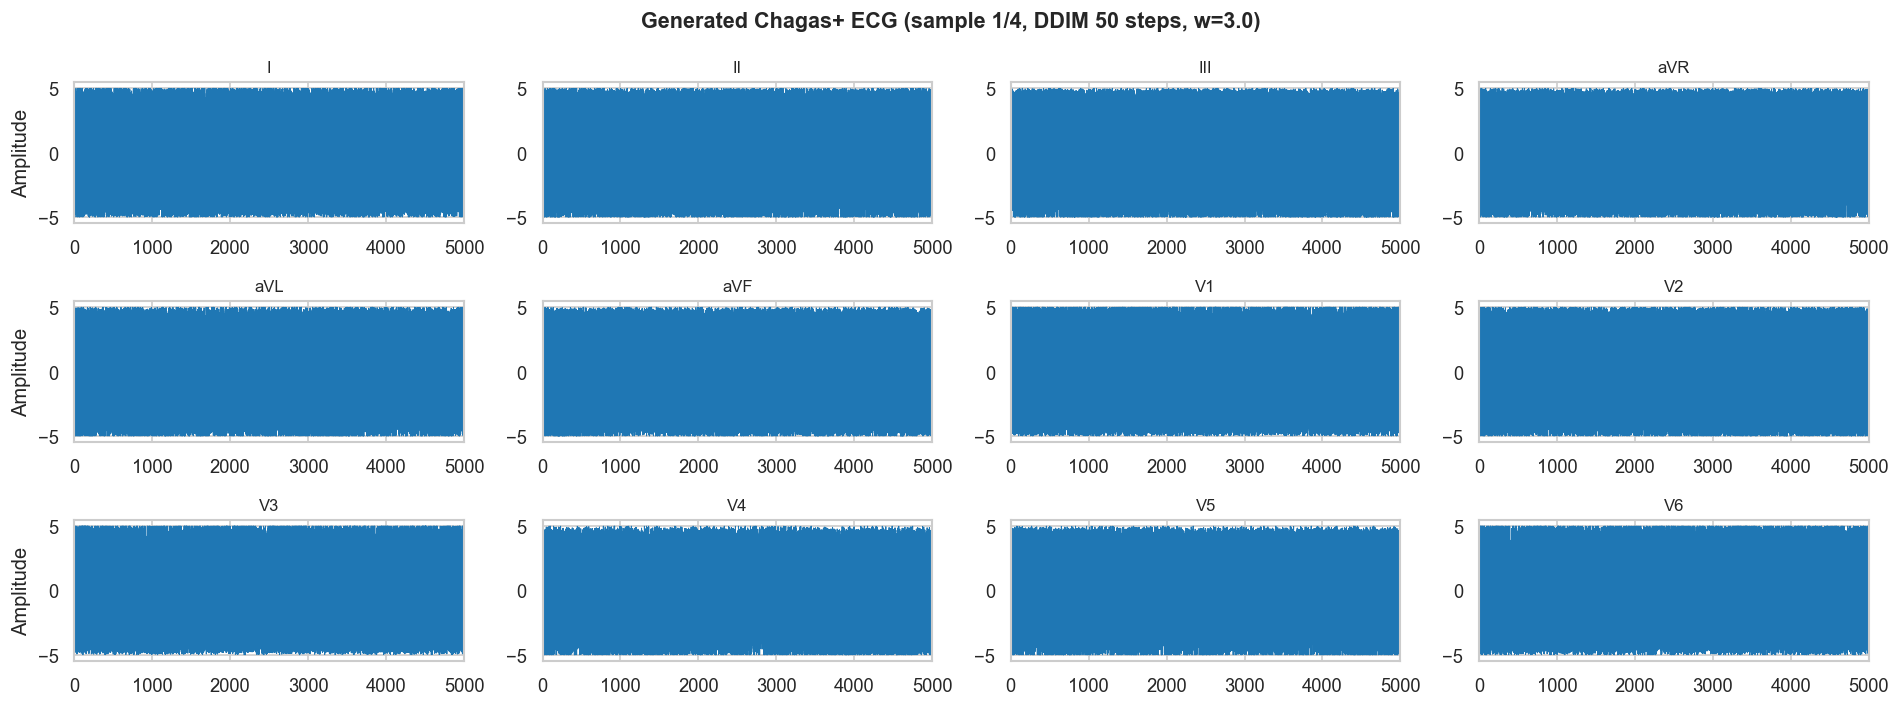

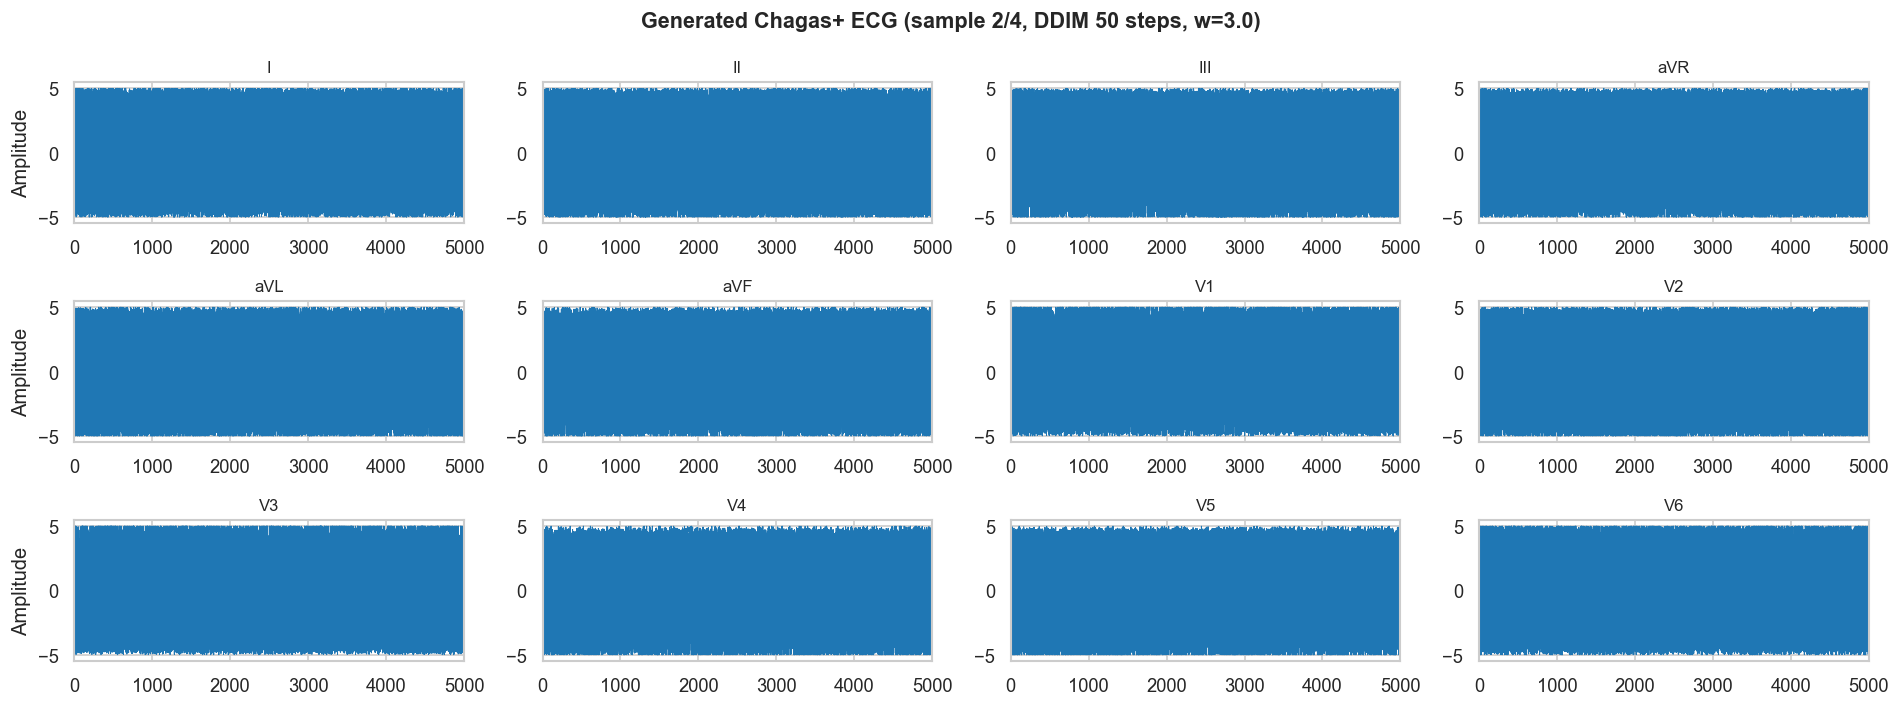

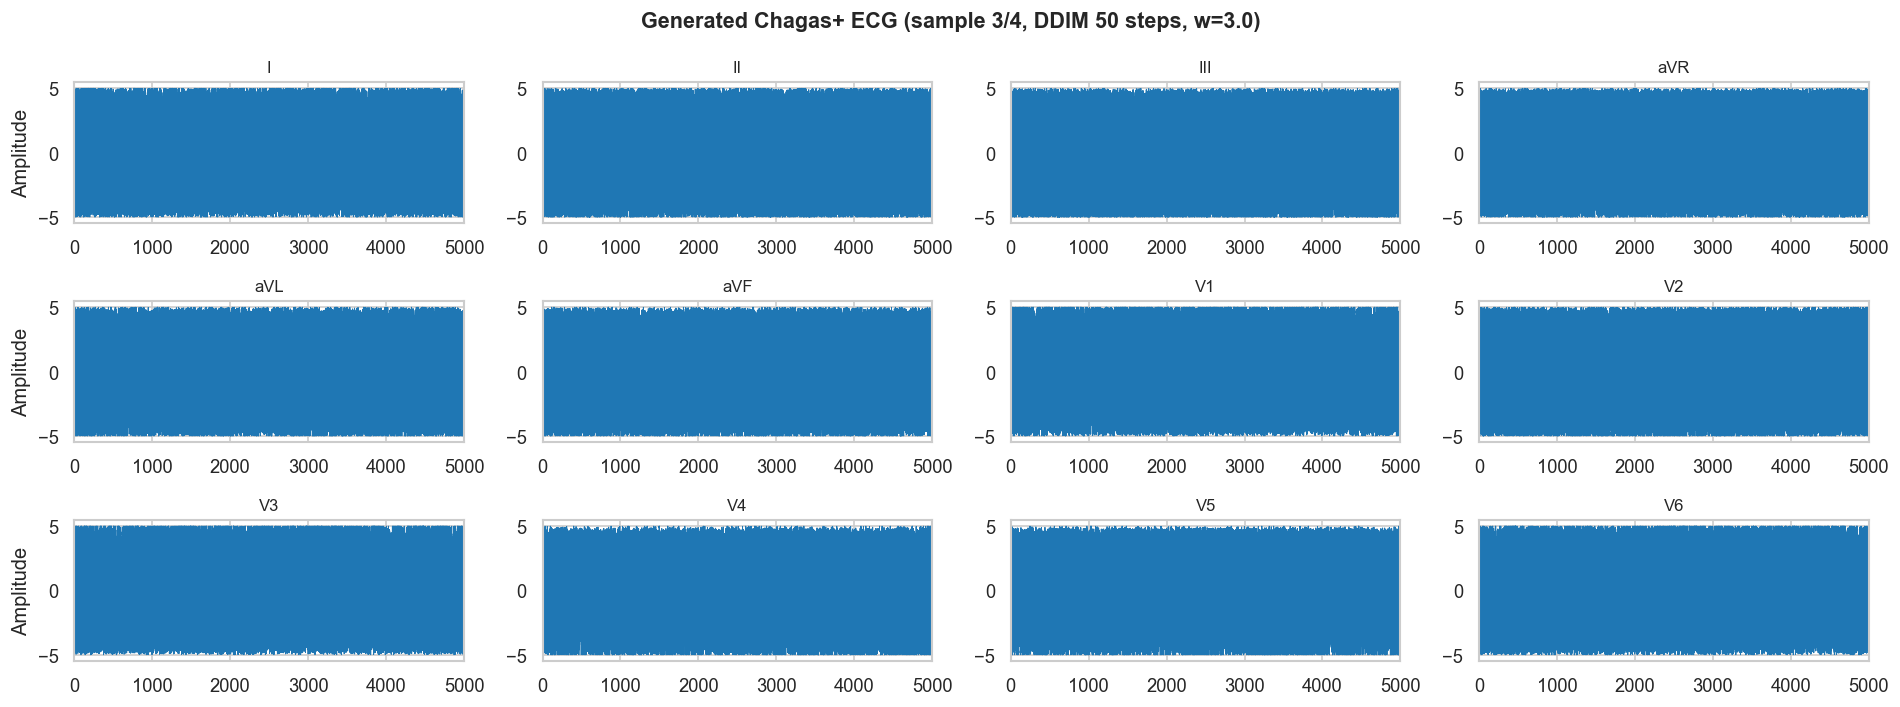

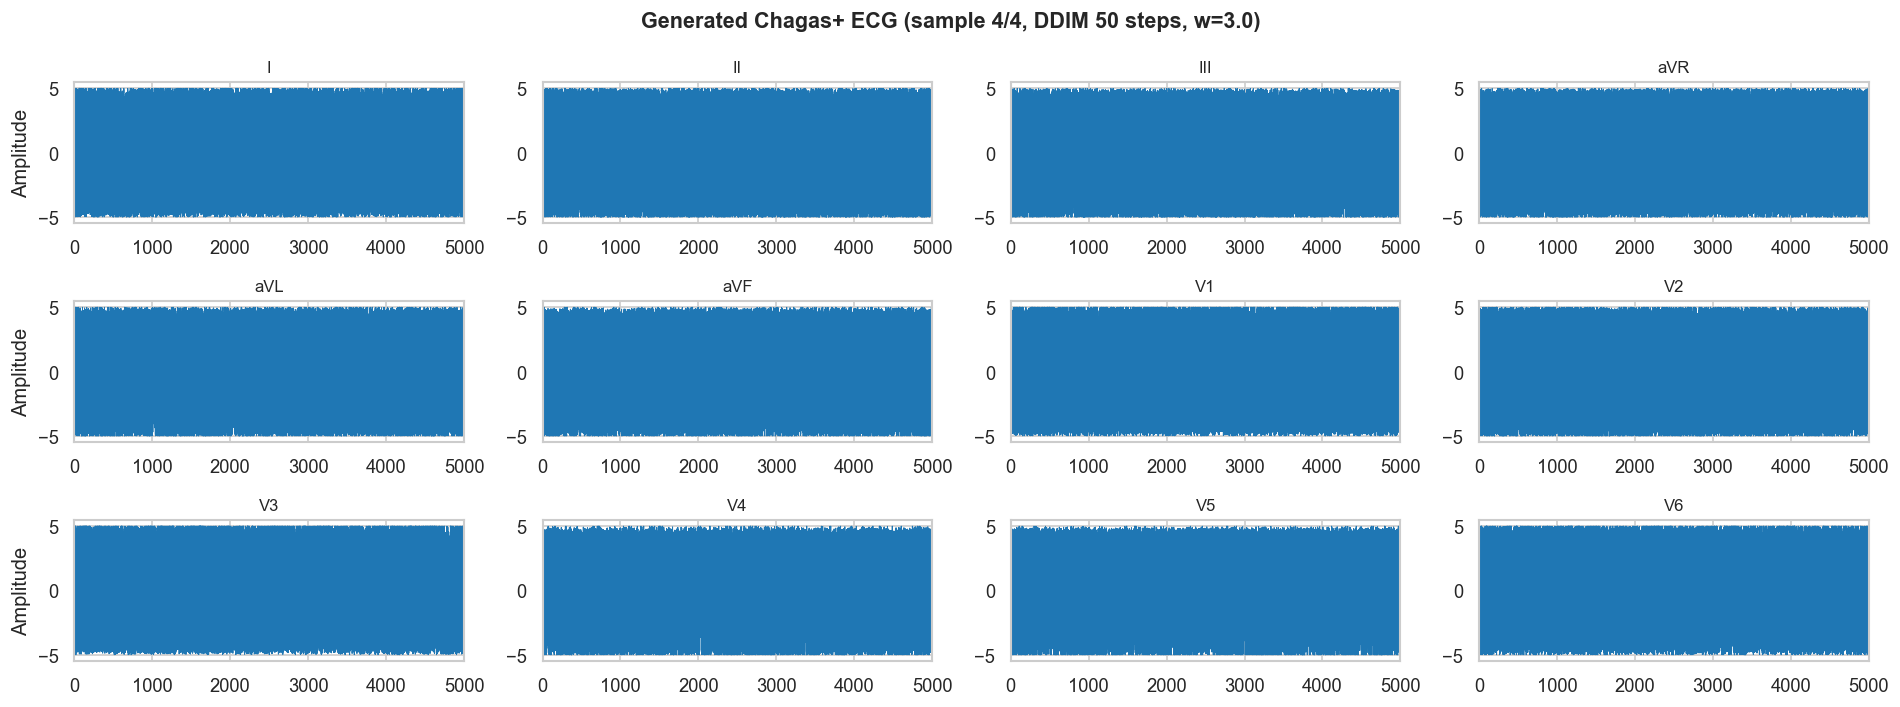

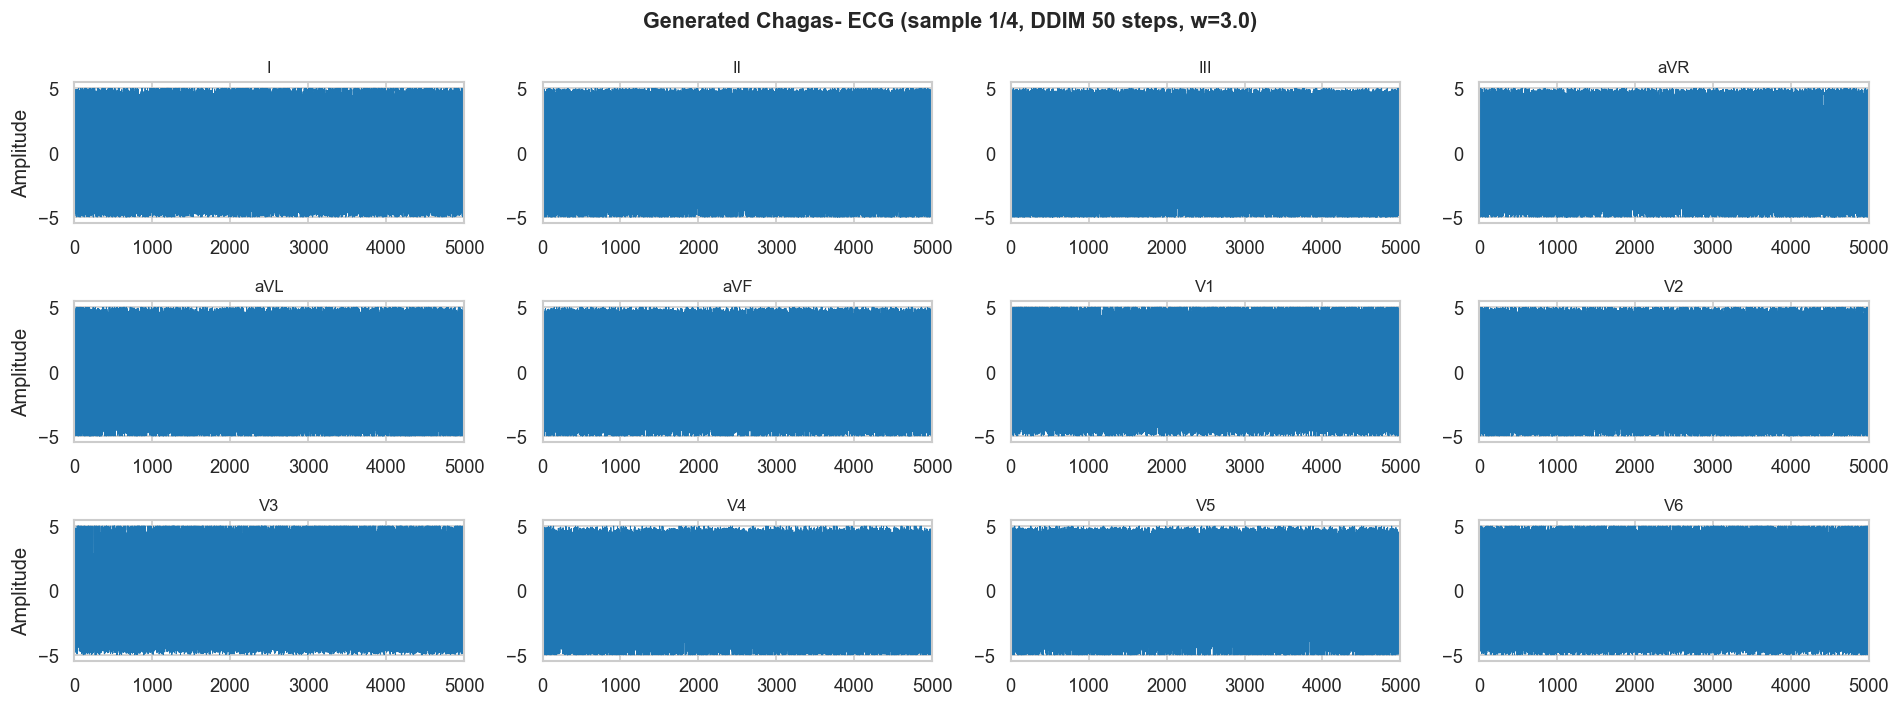

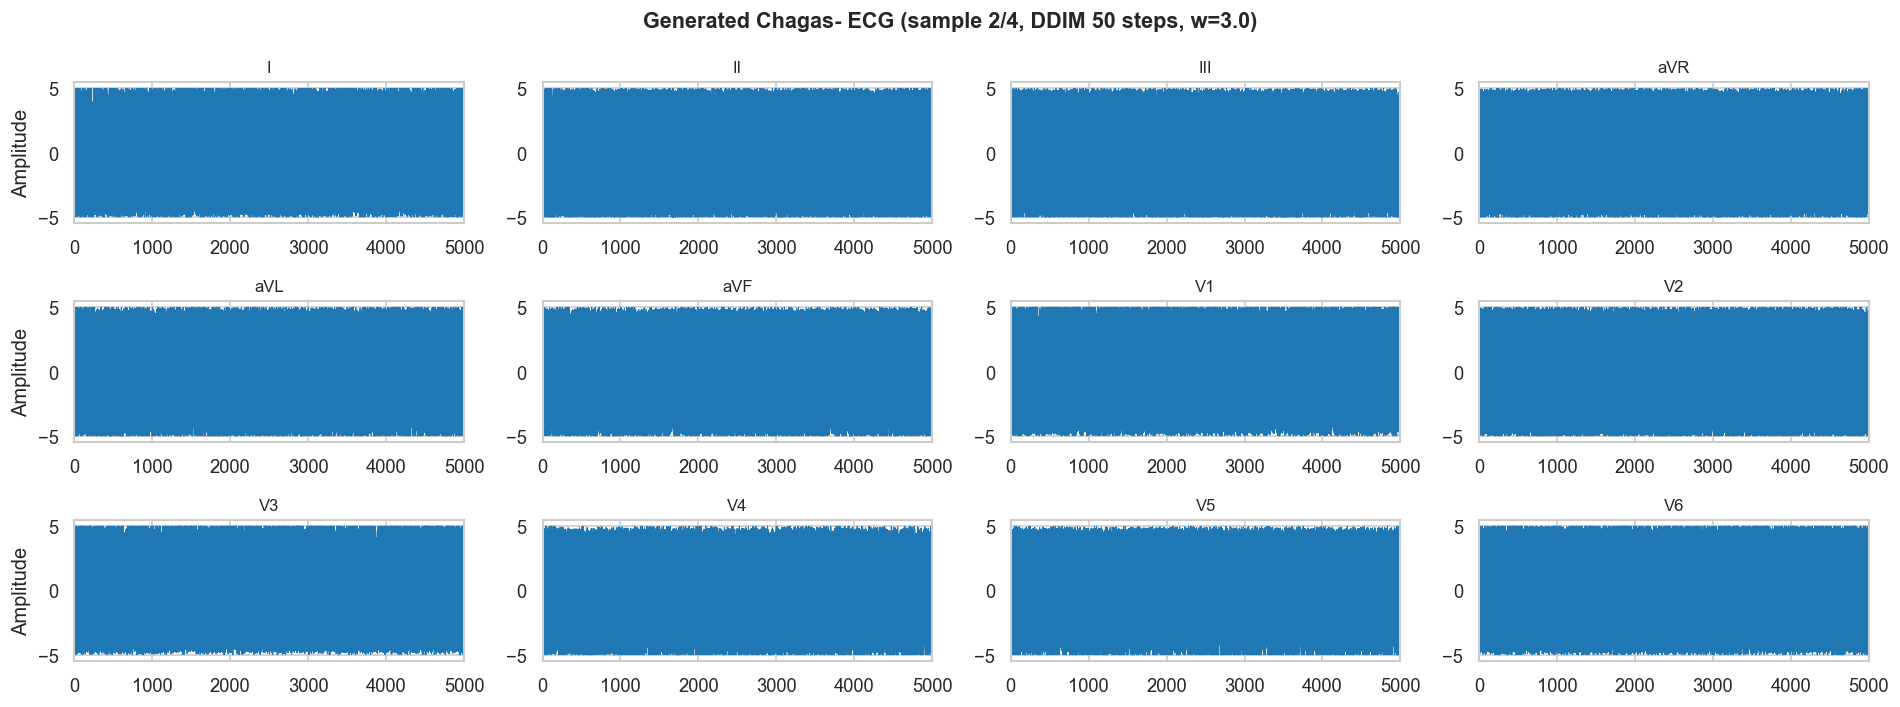

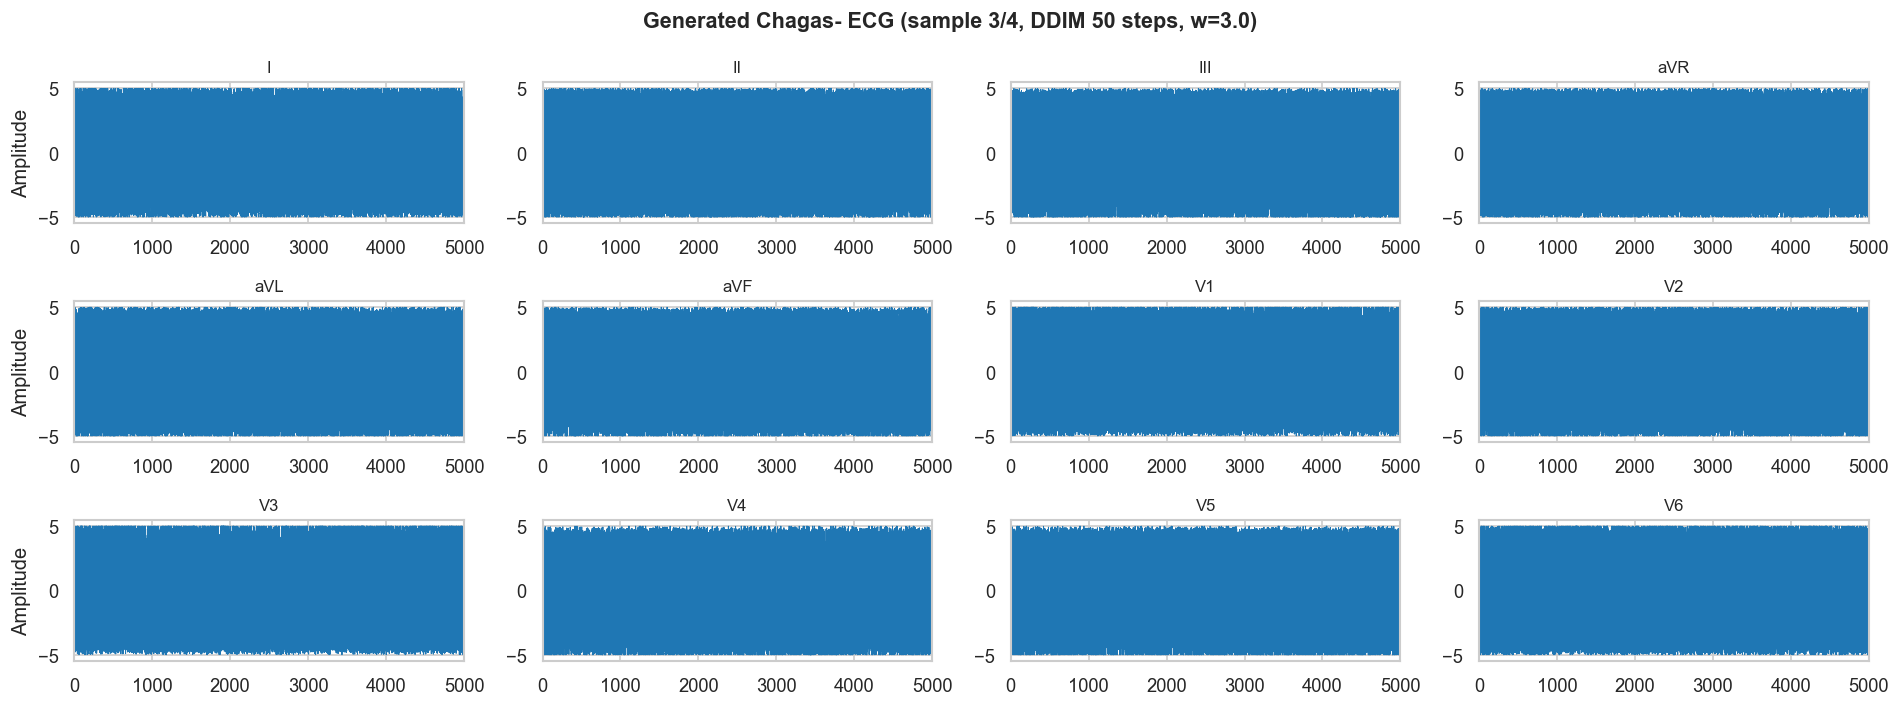

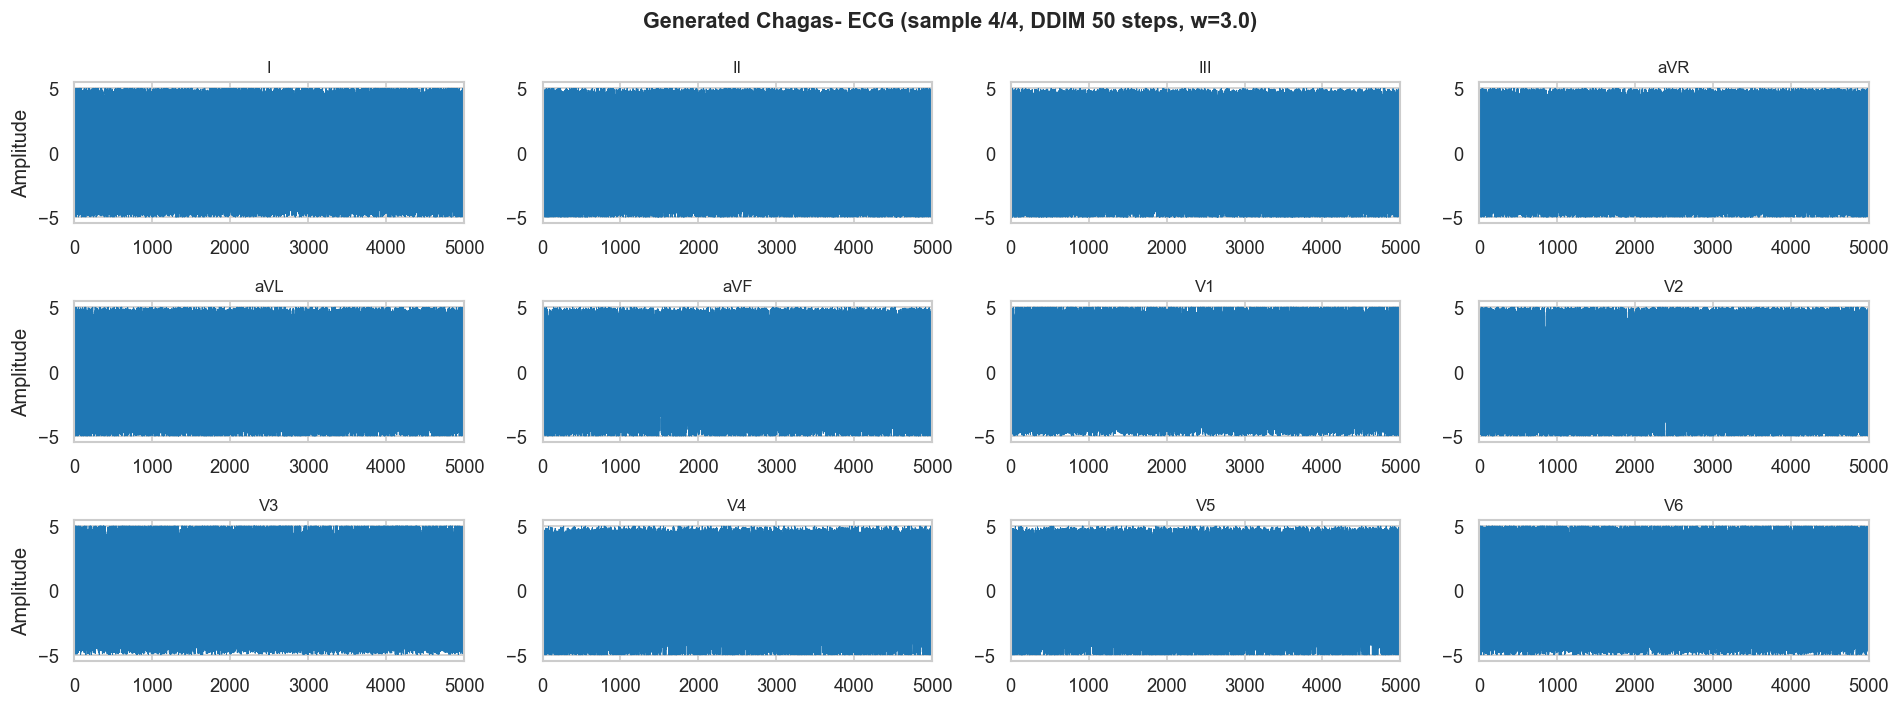

In [37]:
torch.manual_seed(42)
np.random.seed(42)

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

N_SAMPLES = 4

for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
    y_gen = torch.full((N_SAMPLES,), label, device=device, dtype=torch.long)
    samples = ddim_sample(
        unet, schedule, (N_SAMPLES, 12, SEQ_LEN), y_gen, CFG, device,
        steps=CFG["ddim_steps"], eta=CFG["ddim_eta"],
        guidance_scale=CFG["guidance_scale"],
    ).cpu().numpy()

    for s_idx in range(N_SAMPLES):
        fig, axes = plt.subplots(3, 4, figsize=(16, 6))
        for row in range(3):
            for col in range(4):
                lead_idx = row * 4 + col
                ax = axes[row, col]
                signal = samples[s_idx, lead_idx]
                ax.plot(signal, linewidth=0.6, color="C0")
                ax.set_title(LEAD_NAMES[lead_idx], fontsize=10)
                ax.set_xlim(0, SEQ_LEN)
                yabs = max(abs(signal.min()), abs(signal.max()), 0.5)
                ax.set_ylim(-yabs * 1.1, yabs * 1.1)
                if col == 0:
                    ax.set_ylabel("Amplitude")
        fig.suptitle(
            f"Generated {label_name} ECG (sample {s_idx+1}/{N_SAMPLES}, "
            f"DDIM {CFG['ddim_steps']} steps, w={CFG['guidance_scale']})",
            fontsize=13, fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

# 10. Quantitative Evaluation of Generated ECGs

Compare generated ECGs against held-out real ECGs on PSD (frequency content), amplitude statistics (RMS, peak, per-lead std), and inter-lead correlation.

Generating ECGs for quantitative evaluation...


  Chagas+: (100, 12, 5000)


  Chagas-: (100, 12, 5000)
  Real Chagas+: (100, 12, 5000)
  Real Chagas-: (100, 12, 5000)


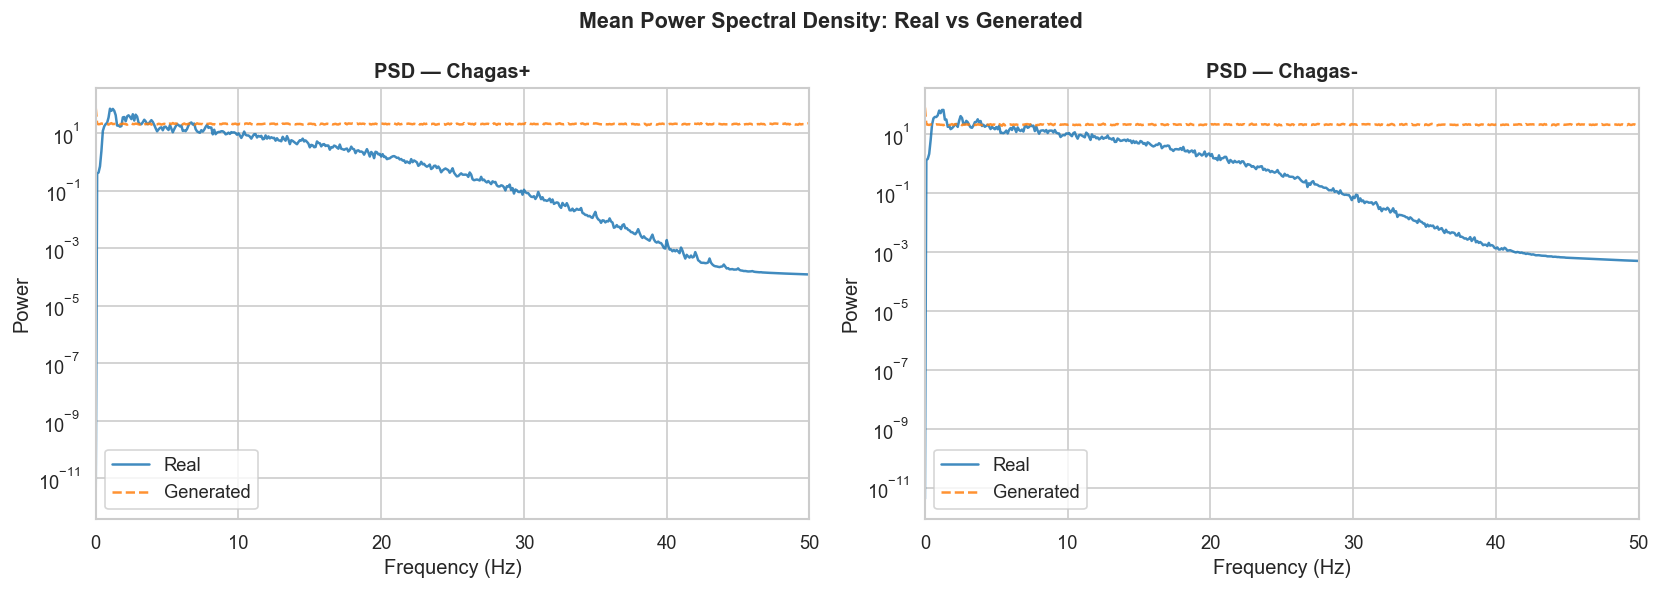


Metric                         Chagas+ Real    Chagas+ Gen   Chagas- Real    Chagas- Gen
------------------------------------------------------------------------------------
  Amplitude rms                        0.9992         4.4957         0.9950         4.4960
  Amplitude std                        0.9992         4.4955         0.9950         4.4959
  Amplitude peak                      15.3338         5.0000        16.4670         5.0000
  Mean inter-lead |corr|                  nan         0.0144            nan         0.0143


/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


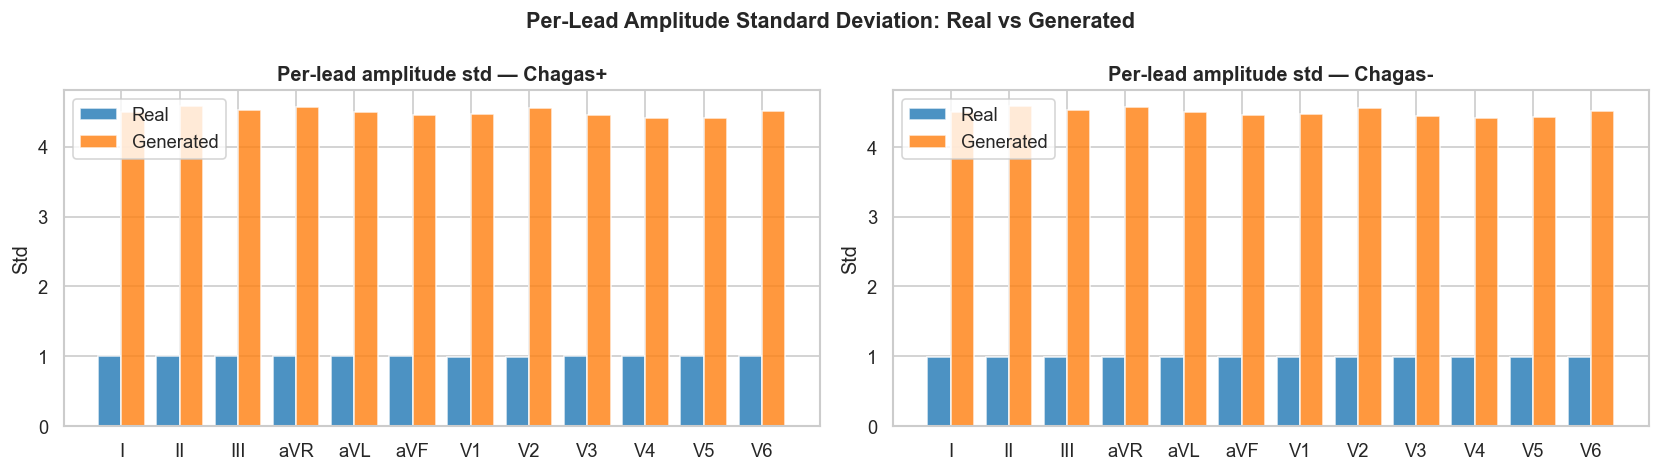


✓ Quantitative evaluation complete.


In [38]:

N_GEN  = 100
N_REAL = 100

print("Generating ECGs for quantitative evaluation...")
torch.manual_seed(0)
generated = {}
for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
    y_eval = torch.full((N_GEN,), label, device=device, dtype=torch.long)
    generated[label_name] = ddim_sample(
        unet, schedule, (N_GEN, 12, SEQ_LEN), y_eval, CFG, device,
        steps=CFG["ddim_steps"], eta=CFG["ddim_eta"],
        guidance_scale=CFG["guidance_scale"],
    ).cpu().numpy()
    print(f"  {label_name}: {generated[label_name].shape}")

real = {}
with h5py.File(cache_file, "r") as f:
    sorted_test_indices = np.sort(test_indices)
    test_lbl = f["labels"][sorted_test_indices]
    for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
        idx = sorted_test_indices[test_lbl == label][:N_REAL]
        real[label_name] = f["signals"][np.sort(idx)]
    print(f"  Real Chagas+: {real['Chagas+'].shape}")
    print(f"  Real Chagas-: {real['Chagas-'].shape}")

def mean_psd(signals, fs=500):
    """Mean one-sided periodogram via FFT, averaged over samples and leads."""
    N = signals.shape[-1]
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    psds  = np.abs(np.fft.rfft(signals, axis=-1)) ** 2 / N
    return freqs, psds.mean(axis=(0, 1))

def amplitude_stats(signals):
    """Return dict with RMS, std, and max-abs across all samples and leads."""
    flat = signals.flatten()
    return {
        "rms":  float(np.sqrt(np.mean(flat ** 2))),
        "std":  float(np.std(flat)),
        "peak": float(np.max(np.abs(flat))),
    }

def mean_inter_lead_corr(signals):
    """Mean absolute Pearson correlation between all lead pairs."""
    n, c, l = signals.shape
    corrs = []
    for s in signals:
        cm = np.corrcoef(s)
        upper = cm[np.triu_indices(c, k=1)]
        corrs.append(np.mean(np.abs(upper)))
    return float(np.mean(corrs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label_name in zip(axes, ["Chagas+", "Chagas-"]):
    f_r, psd_r = mean_psd(real[label_name])
    f_g, psd_g = mean_psd(generated[label_name])
    ax.semilogy(f_r, psd_r, label="Real",      color="C0", alpha=0.85)
    ax.semilogy(f_g, psd_g, label="Generated", color="C1", alpha=0.85, linestyle="--")
    ax.set_xlim(0, 50)
    ax.set_title(f"PSD — {label_name}", fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.legend()

plt.suptitle("Mean Power Spectral Density: Real vs Generated", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<28} {'Chagas+ Real':>14} {'Chagas+ Gen':>14} {'Chagas- Real':>14} {'Chagas- Gen':>14}")
print("-" * 84)
for metric in ["rms", "std", "peak"]:
    vals = [
        amplitude_stats(real["Chagas+"])[metric],
        amplitude_stats(generated["Chagas+"])[metric],
        amplitude_stats(real["Chagas-"])[metric],
        amplitude_stats(generated["Chagas-"])[metric],
    ]
    print(f"  Amplitude {metric:<18} {vals[0]:>14.4f} {vals[1]:>14.4f} {vals[2]:>14.4f} {vals[3]:>14.4f}")

ilc_vals = [
    mean_inter_lead_corr(real["Chagas+"]),
    mean_inter_lead_corr(generated["Chagas+"]),
    mean_inter_lead_corr(real["Chagas-"]),
    mean_inter_lead_corr(generated["Chagas-"]),
]
print(f"  Mean inter-lead |corr|       {ilc_vals[0]:>14.4f} {ilc_vals[1]:>14.4f} {ilc_vals[2]:>14.4f} {ilc_vals[3]:>14.4f}")

LEAD_NAMES_LOCAL = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label_name in zip(axes, ["Chagas+", "Chagas-"]):
    r_std = real[label_name].std(axis=(0, 2))
    g_std = generated[label_name].std(axis=(0, 2))
    x = np.arange(12)
    ax.bar(x - 0.2, r_std, 0.4, label="Real",      color="C0", alpha=0.8)
    ax.bar(x + 0.2, g_std, 0.4, label="Generated", color="C1", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(LEAD_NAMES_LOCAL)
    ax.set_title(f"Per-lead amplitude std — {label_name}", fontweight="bold")
    ax.set_ylabel("Std")
    ax.legend()

plt.suptitle("Per-Lead Amplitude Standard Deviation: Real vs Generated", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n✓ Quantitative evaluation complete.")

# 11. Generative Quality: FID-like Metric and Classifier Fidelity

Two metrics beyond PSD/amplitude:

- Fréchet distance between real and generated ECGs in a 60-d spectral feature space (mean PSD in 5 bands x 12 leads). Lower is better.
- TSTR (train on synthetic, test on real): logistic classifier trained on generated ECGs only, evaluated on the real held-out test set. Accuracy close to the real-trained baseline means the generated distribution is faithful.

Both metrics operate on a coarse 60-d spectral feature space, so they capture gross frequency content but miss morphology. Treat the numbers as a lower-bound signal.

In [39]:

from scipy.linalg import sqrtm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

N_FD   = 200
N_TSTR = 200

print("Generating synthetic ECGs for quality evaluation...")
torch.manual_seed(1)
synth = {}
for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
    y_ = torch.full((N_FD,), label, device=device, dtype=torch.long)
    synth[label] = ddim_sample(
        unet, schedule, (N_FD, 12, SEQ_LEN), y_, CFG, device,
        steps=CFG["ddim_steps"], eta=CFG["ddim_eta"],
        guidance_scale=CFG["guidance_scale"],
    ).cpu().numpy()
    print(f"  Generated {N_FD} {label_name} ECGs")

real_fd = {}
with h5py.File(cache_file, "r") as f:
    sorted_test_indices = np.sort(test_indices)
    test_lbl = f["labels"][sorted_test_indices]
    for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
        idx = sorted_test_indices[test_lbl == label][:N_FD]
        real_fd[label] = f["signals"][np.sort(idx)]
    print(f"  Loaded {N_FD} real Chagas+ and {N_FD} real Chagas- ECGs from test set")

_BANDS = [(0, 5), (5, 15), (15, 40), (40, 100), (100, 250)]

def spectral_features(signals, fs=500):
    """
    Returns (N, 60) feature matrix:
    mean power in 5 frequency bands × 12 leads.
    """
    N, C, L = signals.shape
    freqs = np.fft.rfftfreq(L, d=1.0 / fs)
    psd   = np.abs(np.fft.rfft(signals, axis=-1)) ** 2 / L
    feats = []
    for lo, hi in _BANDS:
        mask = (freqs >= lo) & (freqs < hi)
        feats.append(psd[:, :, mask].mean(axis=-1))
    return np.concatenate(feats, axis=1)

def frechet_distance(feats_real, feats_gen):
    """Fréchet Distance between two multivariate Gaussians."""
    mu_r, mu_g = feats_real.mean(0), feats_gen.mean(0)
    cov_r = np.cov(feats_real, rowvar=False)
    cov_g = np.cov(feats_gen,  rowvar=False)
    diff  = mu_r - mu_g

    covmean = sqrtm(cov_r @ cov_g)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fd = float(diff @ diff + np.trace(cov_r + cov_g - 2 * covmean))
    return fd

print("\nComputing spectral features...")
feats_r_pos = spectral_features(real_fd[1])
feats_r_neg = spectral_features(real_fd[0])
feats_g_pos = spectral_features(synth[1])
feats_g_neg = spectral_features(synth[0])

fd_pos = frechet_distance(feats_r_pos, feats_g_pos)
fd_neg = frechet_distance(feats_r_neg, feats_g_neg)
fd_all = frechet_distance(
    np.vstack([feats_r_pos, feats_r_neg]),
    np.vstack([feats_g_pos, feats_g_neg]),
)
print(f"  Fréchet Distance — Chagas+:  {fd_pos:.4f}")
print(f"  Fréchet Distance — Chagas-:  {fd_neg:.4f}")
print(f"  Fréchet Distance — combined: {fd_all:.4f}")
print("  (lower is better; 0 = distributions identical)")

print("\nTSTR evaluation...")

X_synth = np.vstack([feats_g_pos[:N_TSTR], feats_g_neg[:N_TSTR]])
y_synth = np.array([1] * N_TSTR + [0] * N_TSTR)

with h5py.File(cache_file, "r") as f:
    sorted_train_indices = np.sort(train_indices)
    tr_lbl = f["labels"][sorted_train_indices]
    idx_pos = sorted_train_indices[tr_lbl == 1][:N_TSTR]
    idx_neg = sorted_train_indices[tr_lbl == 0][:N_TSTR]
    real_tr_pos = f["signals"][np.sort(idx_pos)]
    real_tr_neg = f["signals"][np.sort(idx_neg)]
X_real_tr = np.vstack([spectral_features(real_tr_pos), spectral_features(real_tr_neg)])
y_real_tr  = np.array([1] * N_TSTR + [0] * N_TSTR)

X_test = np.vstack([feats_r_pos, feats_r_neg])
y_test = np.array([1] * len(feats_r_pos) + [0] * len(feats_r_neg))

results = {}
for name, X_tr, y_tr in [
    ("TRTR (real→real, upper bound)", X_real_tr, y_real_tr),
    ("TSTR (synthetic→real)",         X_synth,   y_synth),
]:
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(scaler.fit_transform(X_tr), y_tr)
    acc = clf.score(scaler.transform(X_test), y_test)
    auroc = roc_auc_score(y_test, clf.predict_proba(scaler.transform(X_test))[:, 1])
    results[name] = {"accuracy": acc, "auroc": auroc}
    print(f"  {name}")
    print(f"    Accuracy: {acc:.4f}  |  AUROC: {auroc:.4f}")

tstr_gap = results["TRTR (real→real, upper bound)"]["auroc"] - results["TSTR (synthetic→real)"]["auroc"]
print(f"\n  TSTR AUROC gap (lower is better): {tstr_gap:.4f}")
print("  Interpretation: gap < 0.05 → generated ECGs are faithful; gap > 0.15 → significant quality issues")
print("\n✓ Quality evaluation complete.")

Generating synthetic ECGs for quality evaluation...


  Generated 200 Chagas+ ECGs


  Generated 200 Chagas- ECGs
  Loaded 200 real Chagas+ and 200 real Chagas- ECGs from test set

Computing spectral features...
  Fréchet Distance — Chagas+:  16829.3674
  Fréchet Distance — Chagas-:  16443.5924
  Fréchet Distance — combined: 16617.8564
  (lower is better; 0 = distributions identical)

TSTR evaluation...
  TRTR (real→real, upper bound)
    Accuracy: 0.6250  |  AUROC: 0.6830
  TSTR (synthetic→real)
    Accuracy: 0.5000  |  AUROC: 0.5011

  TSTR AUROC gap (lower is better): 0.1819
  Interpretation: gap < 0.05 → generated ECGs are faithful; gap > 0.15 → significant quality issues

✓ Quality evaluation complete.
